In [1]:
%matplotlib inline
import os, sys, copy
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset

from src import (
    bft, collect_layer_data,
    extract_tree_nodes, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
)

DEVICE = ('cuda' if torch.cuda.is_available() else
          'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')
matplotlib.rcParams.update({"figure.dpi": 80})


Device: cuda


# Notebook 08: Stimulus-Conditioned BFT Factor Analysis — CIFAR-10 SmallCNN

Same analysis pipeline as Notebooks 06 and 07, applied to a **convolutional network**
(SmallCNN: 3 conv layers + 2 FC layers) trained on CIFAR-10 (10 classes, 32×32 RGB).

**Key differences from Notebooks 06/07:**
- Model uses Conv2d layers → BFT in **layer-dict mode** (not model-protocol mode).
- Data collection via `collect_layer_data` (hook-based, captures conv + fc layer inputs).
- Image display uses `imdenorm` to reverse CIFAR-10 normalisation for RGB display.
- **Real OOD = CIFAR-100**: same 32×32 RGB format, 100 different categories (domain shift).
- **Far OOD**: synthetic 3-channel images (noise, gray, checkerboard, inverted).

**Section 1** — Model definition, data loading, BFT run (layer-dict mode).

**Section 2** — Factor tree visualisation per output/leaf factor.

**Section 3** — Factor fingerprints & pairwise stimulus similarity.

**Section 4** — ID sanity check: training vs. test (CIFAR-10 samples).

**Section 5** — Real OOD: CIFAR-100 projected onto fixed BFT factors.

**Section 5b** — Far OOD: synthetic 3-channel images.

## Section 1: Model Definition, Data Loading, BFT

In [2]:
class SmallCNN(nn.Module):
    """3-conv + 2-FC CIFAR-10 classifier (matches checkpoint from notebook 04).

    conv1 (3→8)  BN ReLU MaxPool(2)          input (N,3,32,32)
    conv2 (8→16) BN ReLU MaxPool(2)          input (N,8,16,16)
    conv3 (16→32) BN ReLU AdaptiveAvgPool(4) input (N,16,8,8)
    fc1   (512→32) ReLU                      input (N,512)
    fc2   (32→10) log_softmax                input (N,32)
    """
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3,  8,  3, padding=1)
        self.bn1     = nn.BatchNorm2d(8)
        self.conv2   = nn.Conv2d(8,  16, 3, padding=1)
        self.bn2     = nn.BatchNorm2d(16)
        self.conv3   = nn.Conv2d(16, 32, 3, padding=1)
        self.bn3     = nn.BatchNorm2d(32)
        self.pool    = nn.MaxPool2d(2)
        self.avgpool = nn.AdaptiveAvgPool2d(4)
        self.fc1     = nn.Linear(32 * 4 * 4, 32)
        self.fc2     = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.avgpool(F.relu(self.bn3(self.conv3(x))))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return F.log_softmax(self.fc2(x), dim=1)


CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
CLASS_NAMES = {i: CIFAR10_CLASSES[i] for i in range(10)}
IMAGE_SIDE  = 32
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR10_STD  = np.array([0.2470, 0.2435, 0.2616])


def imdenorm(img, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Reverse CIFAR-10 normalisation for display. img: (3,H,W) → (H,W,3) in [0,1]."""
    m = mean[None, None, :]; s = std[None, None, :]
    return np.clip(img.transpose(1, 2, 0) * s + m, 0, 1)


print(f'SmallCNN defined. Classes: {CIFAR10_CLASSES}')

SmallCNN defined. Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# ── BFT configuration (layer-dict mode, forward order: conv1, conv2, conv3, fc1, fc2) ──
N_BRANCHES      = [1, 1, 1, 2, 10]    # 5 branches at fc2 (output), 2 at fc1, single path in conv layers
K_MAX           = [8, 8, 8, 8, 10]   # up to 10 factors at fc2 (one per class)
POOL_METHOD     = 'avg'               # spatial pooling for conv layers
STIM_THRESHOLD  = 0.0
AUTO_THRESHOLD  = 0.90
TOP_N_FACTOR    = 50
N_TOP_PER_CLASS = 200                  # confidence-filter samples per class (see Section 1c)
DATA_DIR        = '../data'
WEIGHTS_PATH    = os.path.join(DATA_DIR, 'cache', 'nb04', 'weights', 'weights.pt')

normalize = T.Normalize(CIFAR10_MEAN, CIFAR10_STD)
test_tf   = T.Compose([T.ToTensor(), normalize])

model = SmallCNN().to(DEVICE)

if os.path.exists(WEIGHTS_PATH):
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
    print(f'Loaded weights from {WEIGHTS_PATH}')
else:
    NB08_WEIGHTS = os.path.join(DATA_DIR, 'cache', 'nb08', 'weights', 'weights.pt')
    os.makedirs(os.path.dirname(NB08_WEIGHTS), exist_ok=True)
    if os.path.exists(NB08_WEIGHTS):
        model.load_state_dict(torch.load(NB08_WEIGHTS, map_location=DEVICE))
        print(f'Loaded weights from {NB08_WEIGHTS}')
    else:
        print('No saved weights found — training SmallCNN from scratch (~10 min on CPU, ~2 min on GPU)')
        N_EPOCHS = 150
        train_tf_aug = T.Compose([
            T.RandomCrop(32, 4), T.RandomHorizontalFlip(), T.ToTensor(), normalize,
        ])
        _train_ds = torchvision.datasets.CIFAR10(DATA_DIR, True,  download=True, transform=train_tf_aug)
        _test_ds  = torchvision.datasets.CIFAR10(DATA_DIR, False, download=True, transform=test_tf)
        _tr = DataLoader(_train_ds, 128, shuffle=True,  num_workers=0, pin_memory=True)
        _te = DataLoader(_test_ds,  256, shuffle=False, num_workers=0)
        opt  = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
        sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
        crit = nn.NLLLoss()
        for ep in range(1, N_EPOCHS + 1):
            model.train()
            nc, nt = 0, 0
            for x, y in _tr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                out = model(x); loss = crit(out, y); loss.backward(); opt.step()
                nc += (out.argmax(1) == y).sum().item(); nt += y.size(0)
            sch.step()
            if ep % 20 == 0 or ep == N_EPOCHS:
                model.eval()
                tc = ts = 0
                with torch.no_grad():
                    for x, y in _te:
                        x, y = x.to(DEVICE), y.to(DEVICE)
                        tc += (model(x).argmax(1) == y).sum().item(); ts += y.size(0)
                print(f'Ep {ep:3d} | train {nc/nt:.3f} | test {tc/ts:.3f}')
        torch.save(model.state_dict(), NB08_WEIGHTS)
        print(f'Saved to {NB08_WEIGHTS}')
        WEIGHTS_PATH = NB08_WEIGHTS

model.eval()

# Per-class test accuracy
test_ds = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_ds, 256, shuffle=False, num_workers=0)

pc_correct = defaultdict(int); pc_total = defaultdict(int)
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x).argmax(1)
        for t, p in zip(y.cpu().tolist(), preds.cpu().tolist()):
            pc_total[t] += 1; pc_correct[t] += int(t == p)

print(f'\n{"Class":<14} {"Acc":>6}')
print('-' * 22)
for c in range(10):
    print(f'{CIFAR10_CLASSES[c]:<14} {pc_correct[c]/pc_total[c]:>6.3f}')
print(f'{"Overall":<14} {sum(pc_correct.values())/sum(pc_total.values()):>6.3f}')
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)
FIG_DIR   = os.path.join(_repo_dir, 'figs', '08_cifar10_stimulus_analysis')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'FIG_DIR: {FIG_DIR}')


Loaded weights from ../data/cache/nb04/weights/weights.pt

Class             Acc
----------------------
airplane        0.833
automobile      0.891
bird            0.699
cat             0.583
deer            0.787
dog             0.729
frog            0.852
horse           0.817
ship            0.862
truck           0.865
Overall         0.792
FIG_DIR: /home/jb3879/Factor_Trace/figs/08_cifar10_stimulus_analysis


In [4]:
# ── 1c: Collect test-set layer data (correctly classified only) ───────────────
# collect_layer_data uses forward hooks on all Conv2d and Linear layers.
# Returns layer_data: list of dicts {name, type, weight, input_fmap, output_fmap}
# in the order: conv1, conv2, conv3, fc1, fc2.

raw_data = collect_layer_data(model, test_loader, DEVICE, only_correct=True)

print(f'Collected {len(raw_data["targets"]):,} correct samples')
print(f'\n{"Layer":<8}  {"Type":<4}  {"Input shape":<22}  {"W shape"}')
print('-' * 60)
for ld in raw_data['layer_data']:
    print(f'{ld["name"]:<8}  {ld["type"]:<4}  {str(ld["input_fmap"].shape):<22}  {str(ld["weight"].shape)}')

# ── Confidence filter: keep top-N_TOP_PER_CLASS per class ────────────────────
def confidence_filter(raw, top_k, n_classes=10):
    keep = np.sort(np.concatenate([
        np.where(raw['targets'] == c)[0][
            np.argsort(raw['confidences'][raw['targets'] == c])[::-1][:top_k]]
        for c in range(n_classes)]))
    images = raw['images'][keep]
    targets = raw['targets'][keep]
    confidences = raw['confidences'][keep]
    layer_data = [
        {**ld, 'input_fmap': ld['input_fmap'][keep],
         'output_fmap': ld['output_fmap'][keep]}
        for ld in raw['layer_data']
    ]
    return {'images': images, 'targets': targets, 'confidences': confidences,
            'layer_data': layer_data}, keep

data, _keep = confidence_filter(raw_data, N_TOP_PER_CLASS)
all_images  = data['images']   # (N, 3, 32, 32) normalised
all_targets = data['targets']  # (N,) class 0–9
n_samples   = len(all_images)
print(f'\nAfter confidence filter (top-{N_TOP_PER_CLASS}/class): N = {n_samples}')
print(f'Class dist: {dict(zip(*np.unique(all_targets, return_counts=True)))}')

Collected 7,918 correct samples

Layer     Type  Input shape             W shape
------------------------------------------------------------
conv1     conv  (7918, 3, 32, 32)       (8, 3, 3, 3)
conv2     conv  (7918, 8, 16, 16)       (16, 8, 3, 3)
conv3     conv  (7918, 16, 8, 8)        (32, 16, 3, 3)
fc1       fc    (7918, 512)             (32, 512)
fc2       fc    (7918, 32)              (10, 32)

After confidence filter (top-200/class): N = 2000
Class dist: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}


In [ ]:
import pickle, pathlib
_BFT_CACHE = pathlib.Path(DATA_DIR) / 'cache' / 'nb08' / 'bft_tree_root.pkl'
_BFT_CACHE.parent.mkdir(parents=True, exist_ok=True)

if _BFT_CACHE.exists():
    with open(_BFT_CACHE, 'rb') as _f:
        tree_root = pickle.load(_f)
    print(f'Loaded tree_root from cache: {_BFT_CACHE}')
else:
    tree_root = bft(
        data['layer_data'],
        k_max             = K_MAX,
        n_branches        = N_BRANCHES,
        conv_pool_method  = POOL_METHOD,
        stimulus_threshold= STIM_THRESHOLD,
        weighting         = 'img_selectivity',
        verbose           = 1,
    )
    with open(_BFT_CACHE, 'wb') as _f:
        pickle.dump(tree_root, _f)
    print(f'Saved tree_root to cache: {_BFT_CACHE}')

tree_nodes   = extract_tree_nodes(tree_root)
factor_nodes = extract_factor_tree_nodes(tree_root)

max_layer_idx = max(e['layer_idx'] for e in tree_nodes)
root_bft_node = tree_root
l0_nodes      = nodes_at_layer(tree_root, 0)  # conv1 leaf nodes

# layer_inputs for projection (used by project_stimuli_onto_tree)
layer_inputs = [ld['input_fmap'] for ld in data['layer_data']]

print(f'\nTree: {len(tree_nodes)} path nodes,  {len(factor_nodes)} factor nodes,  max_layer_idx={max_layer_idx}')
print(f'Root factors (fc2 output layer): K={len(root_bft_node["lambdas"])}')
print(f'L0 leaf nodes (conv1): {len(l0_nodes)}')
for ln in l0_nodes:
    print(f'  path={ln["path"]}  K={len(ln["lambdas"])}')

[BFT] Layer 5/5 'fc2' (fc)  path=[]
[BFT] Layer 4/5 'fc1' (fc)  path=[0]
[BFT] Layer 3/5 'conv3' (conv)  path=[0, 0]
[BFT] Layer 2/5 'conv2' (conv)  path=[0, 0, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[0, 0, 0, 0]
[BFT] Layer 3/5 'conv3' (conv)  path=[0, 1]
[BFT] Layer 2/5 'conv2' (conv)  path=[0, 1, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[0, 1, 0, 0]
[BFT] Layer 4/5 'fc1' (fc)  path=[1]
[BFT] Layer 3/5 'conv3' (conv)  path=[1, 0]
[BFT] Layer 2/5 'conv2' (conv)  path=[1, 0, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[1, 0, 0, 0]
[BFT] Layer 3/5 'conv3' (conv)  path=[1, 1]
[BFT] Layer 2/5 'conv2' (conv)  path=[1, 1, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[1, 1, 0, 0]
[BFT] Layer 4/5 'fc1' (fc)  path=[2]
[BFT] Layer 3/5 'conv3' (conv)  path=[2, 0]
[BFT] Layer 2/5 'conv2' (conv)  path=[2, 0, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[2, 0, 0, 0]
[BFT] Layer 3/5 'conv3' (conv)  path=[2, 1]
[BFT] Layer 2/5 'conv2' (conv)  path=[2, 1, 0]
[BFT] Layer 1/5 'conv1' (conv)  path=[2, 1, 0, 0]
[BFT] L

## Section 2: Factor Tree Visualisation — one tree per factor

- **2a** — Output (fc2 / root) factors: each corresponds to a group of CIFAR-10 classes.
- **2b** — Leaf (conv1 / L0) factors: one subplot per leaf node.

Plotting 10 output-layer factor trees ...


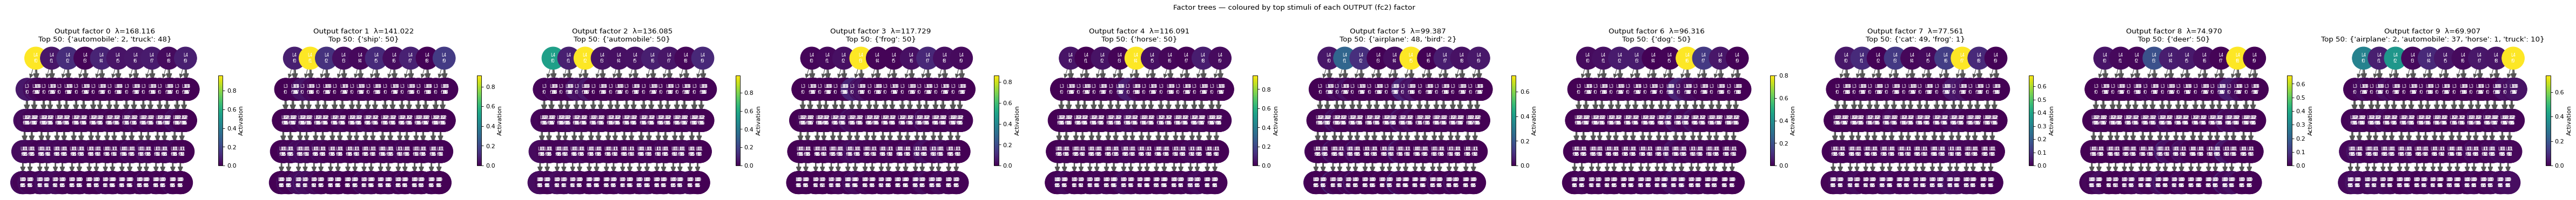

In [6]:
K_root = len(root_bft_node['lambdas'])
print(f'Plotting {K_root} output-layer factor trees ...')

fig, axes = plt.subplots(1, K_root, figsize=(6 * K_root, 4.5), squeeze=False)
axes = axes[0]

for k in range(K_root):
    acts, top_idx = top_stimuli_factor_activations(
        factor_nodes, root_bft_node, k, TOP_N_FACTOR
    )
    lam = root_bft_node['lambdas'][k]
    class_counts = {CIFAR10_CLASSES[c]: int((all_targets[top_idx] == c).sum())
                    for c in sorted(np.unique(all_targets[top_idx]))}
    plot_factor_tree(
        factor_nodes, acts, ax=axes[k],
        title=f'Output factor {k}  λ={lam:.3f}\nTop {len(top_idx)}: {class_counts}',
    )

plt.suptitle('Factor trees — coloured by top stimuli of each OUTPUT (fc2) factor',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tree_output_factors.png'), dpi=120, bbox_inches='tight')
plt.show()

Leaf [0, 0, 0, 0] (conv1): K=6 factors


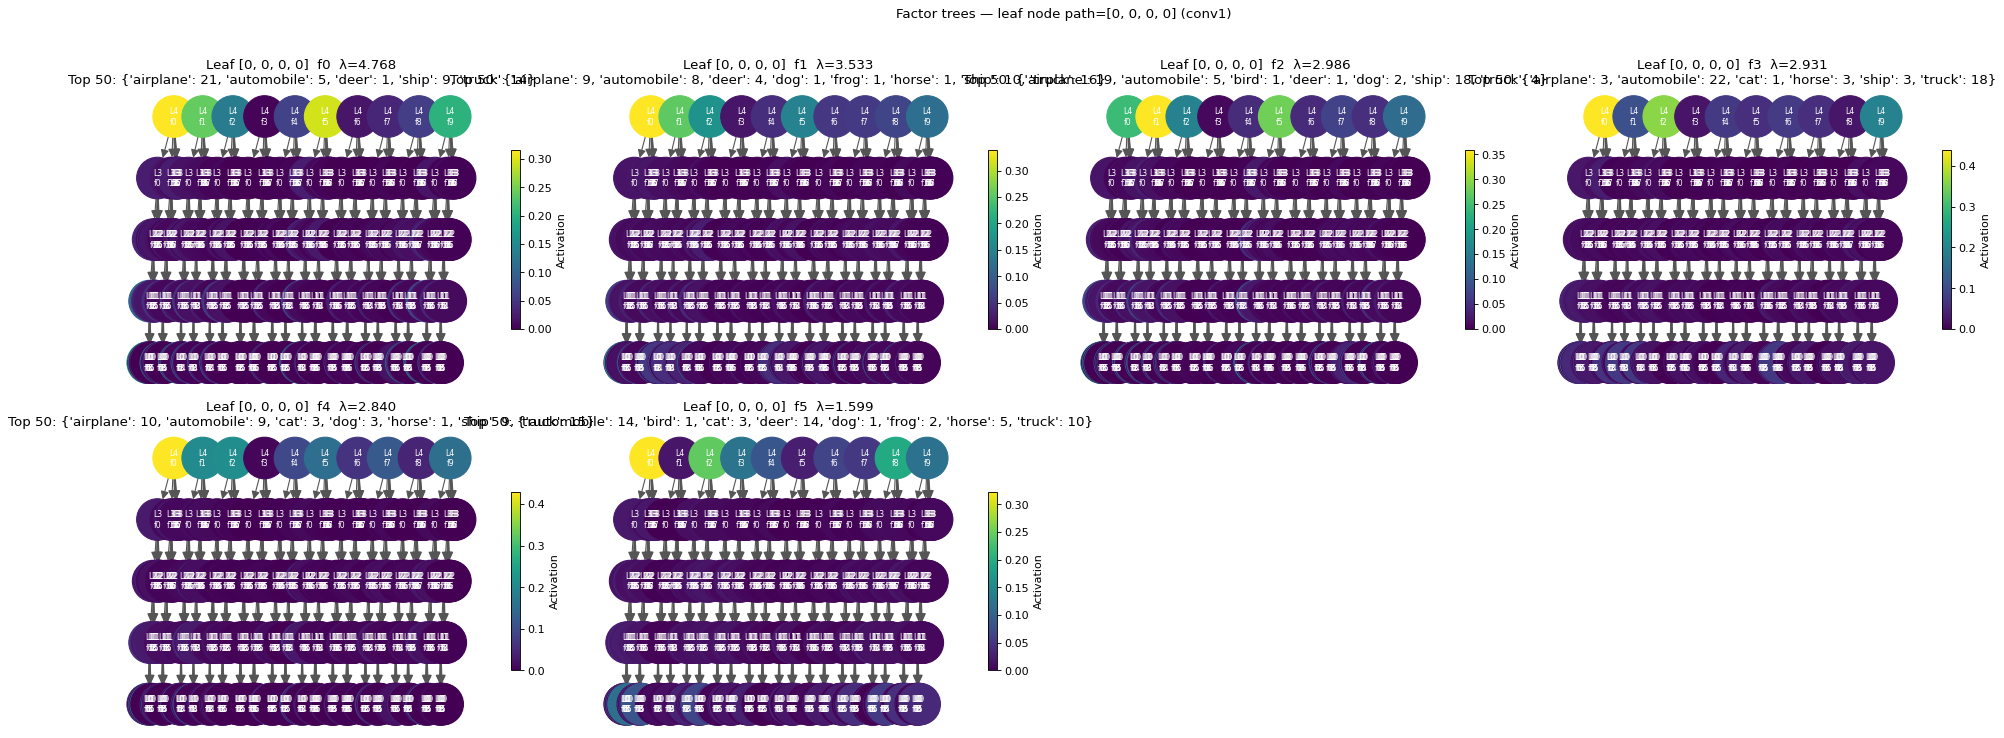

Leaf [0, 1, 0, 0] (conv1): K=6 factors


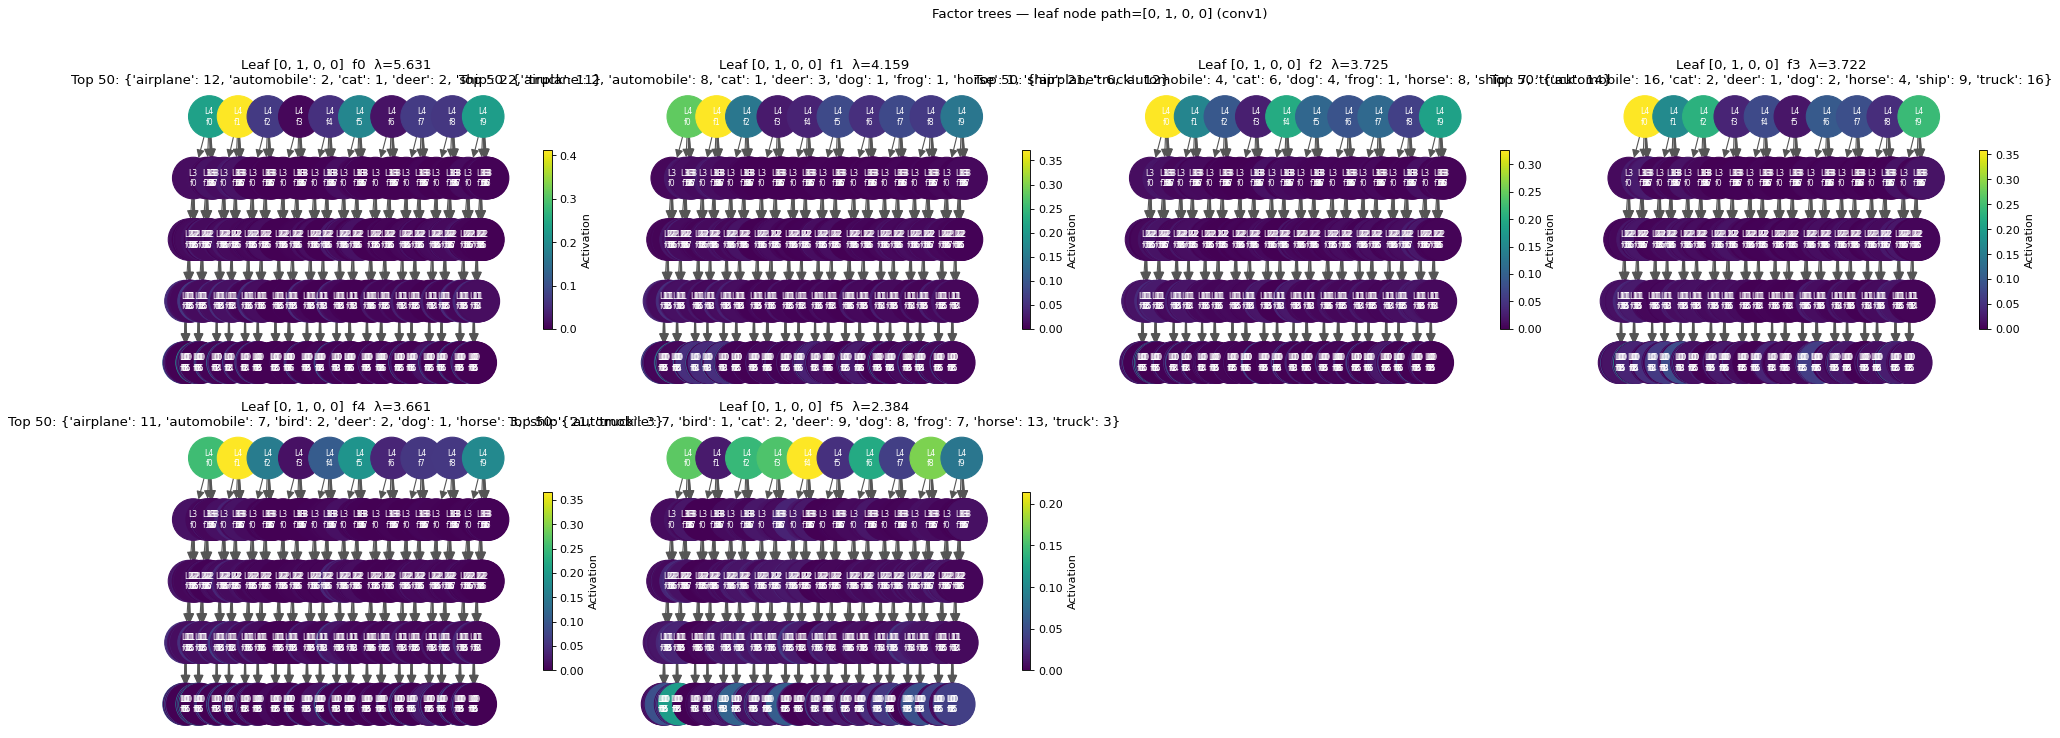

Leaf [1, 0, 0, 0] (conv1): K=5 factors


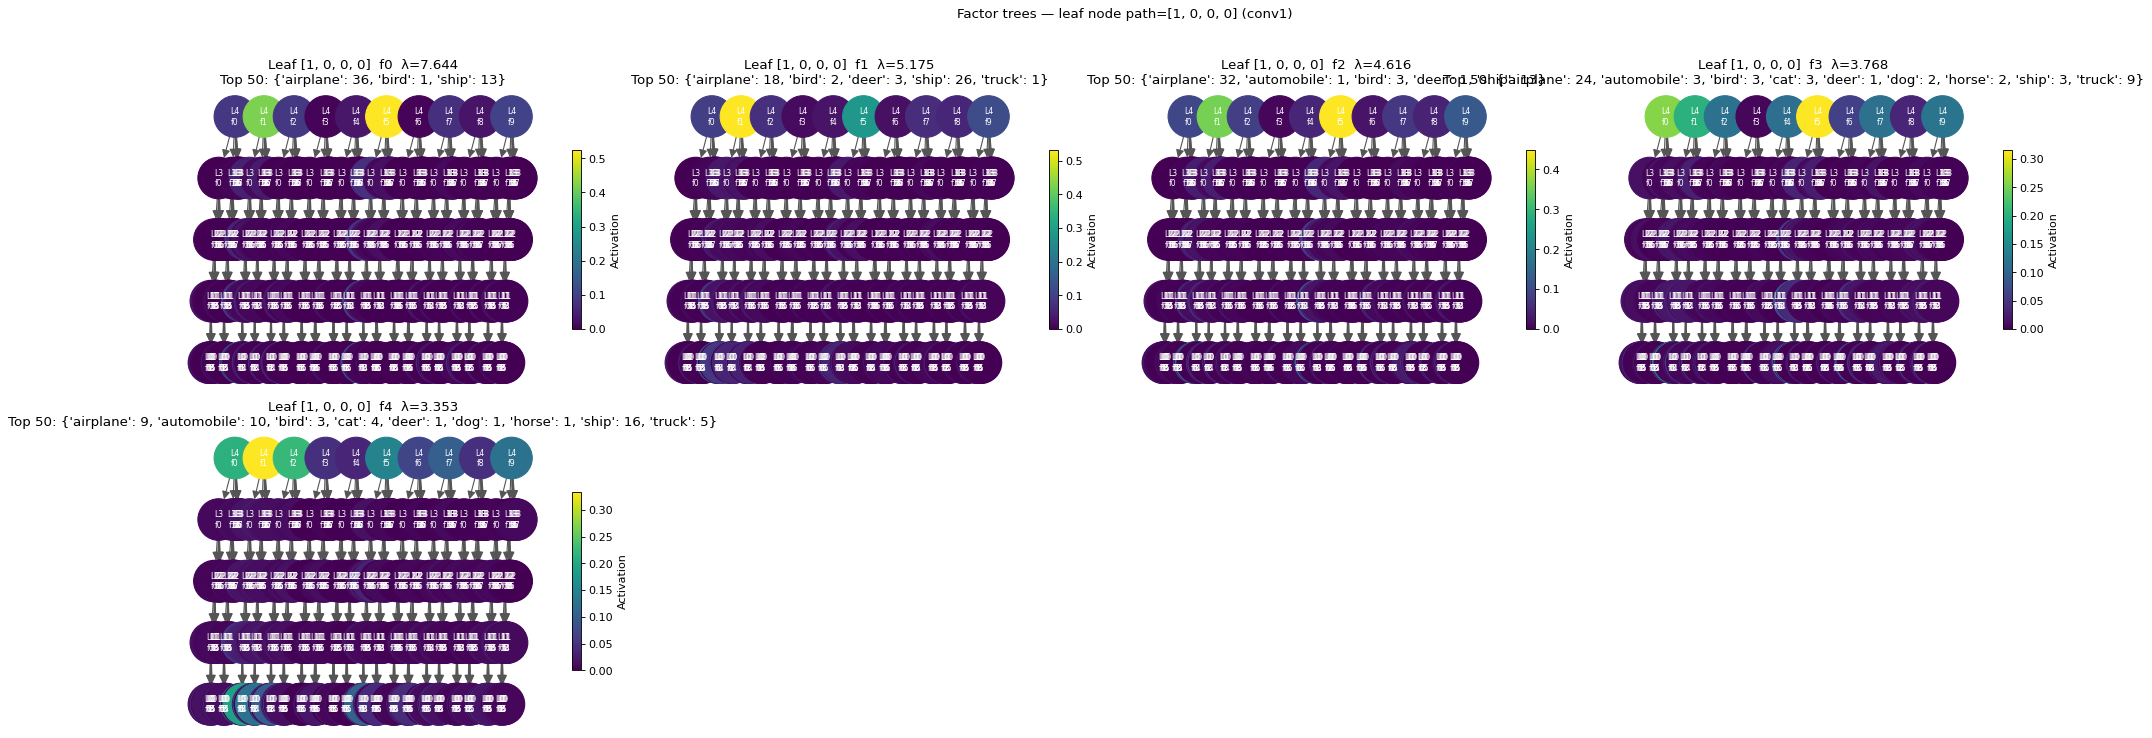

Leaf [1, 1, 0, 0] (conv1): K=5 factors
Leaf [2, 0, 0, 0] (conv1): K=5 factors
Leaf [2, 1, 0, 0] (conv1): K=6 factors
Leaf [3, 0, 0, 0] (conv1): K=6 factors
Leaf [3, 1, 0, 0] (conv1): K=7 factors
Leaf [4, 0, 0, 0] (conv1): K=6 factors
Leaf [4, 1, 0, 0] (conv1): K=6 factors
Leaf [5, 0, 0, 0] (conv1): K=5 factors
Leaf [5, 1, 0, 0] (conv1): K=7 factors
Leaf [6, 0, 0, 0] (conv1): K=6 factors
Leaf [6, 1, 0, 0] (conv1): K=7 factors
Leaf [7, 0, 0, 0] (conv1): K=6 factors
Leaf [7, 1, 0, 0] (conv1): K=6 factors
Leaf [8, 0, 0, 0] (conv1): K=6 factors
Leaf [8, 1, 0, 0] (conv1): K=6 factors
Leaf [9, 0, 0, 0] (conv1): K=6 factors
Leaf [9, 1, 0, 0] (conv1): K=6 factors


In [7]:
_inline_shown_leaf = 0
_MAX_INLINE_leaf   = 3

for leaf in l0_nodes:
    K_leaf   = len(leaf['lambdas'])
    path_str = str(leaf['path'])
    print(f'Leaf {path_str} ({leaf["layer_name"]}): K={K_leaf} factors')

    ncols = min(4, K_leaf)
    nrows = int(np.ceil(K_leaf / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

    for k in range(K_leaf):
        ax = axes[k // ncols][k % ncols]
        acts, top_idx = top_stimuli_factor_activations(
            factor_nodes, leaf, k, TOP_N_FACTOR
        )
        lam = leaf['lambdas'][k]
        class_counts = {CIFAR10_CLASSES[c]: int((all_targets[top_idx] == c).sum())
                        for c in sorted(np.unique(all_targets[top_idx]))}
        plot_factor_tree(
            factor_nodes, acts, ax=ax,
            title=f'Leaf {path_str}  f{k}  λ={lam:.3f}\nTop {len(top_idx)}: {class_counts}',
        )

    for j in range(K_leaf, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    plt.suptitle(f'Factor trees — leaf node path={path_str} ({leaf["layer_name"]})',
                 y=1.02, fontsize=12)
    plt.tight_layout()
    fname = os.path.join(FIG_DIR, f'tree_leaf_{path_str.replace(", ", "-").replace("[", "").replace("]", "")}.png')
    fig.savefig(fname, dpi=120, bbox_inches='tight')
    if _inline_shown_leaf < _MAX_INLINE_leaf:
        _inline_shown_leaf += 1
        plt.show()
    else:
        plt.close(fig)

### 2c: Conv1 Kernel Visualisation

For the conv1 leaf nodes, visualise the top-K output channels by NMF loading as RGB patches.

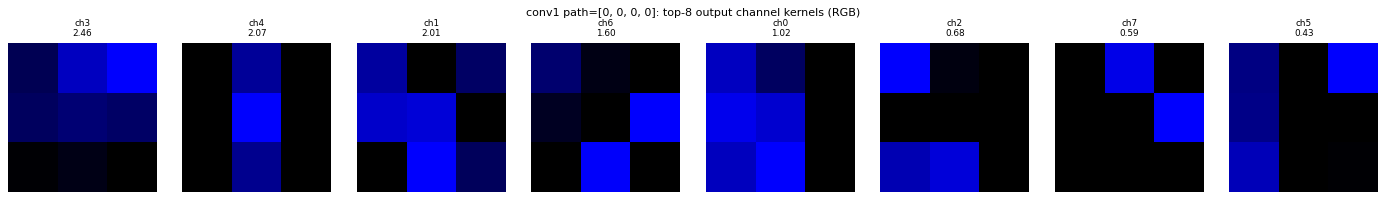

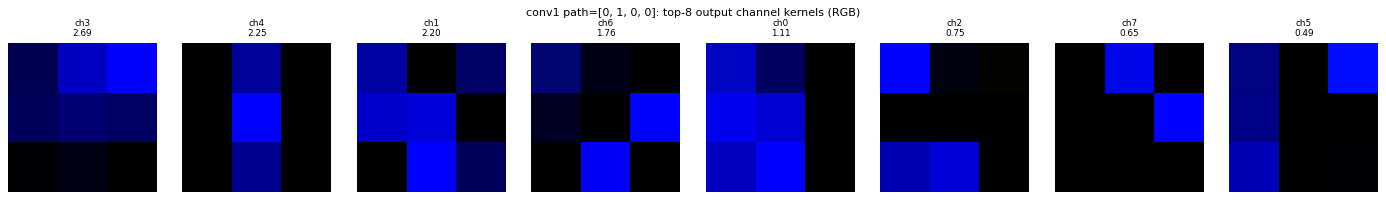

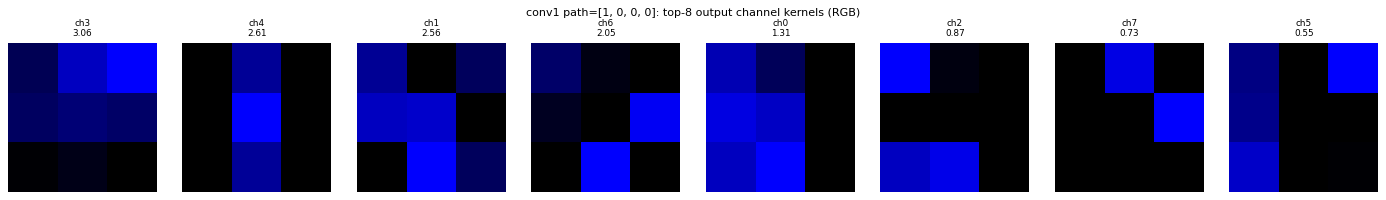

In [8]:
_inline_shown_conv = 0
_MAX_INLINE_conv   = 3

N_SHOW_CHANNELS = 8

for leaf in l0_nodes:
    if leaf['layer_type'] != 'conv':
        continue
    ld = data['layer_data'][leaf['layer_idx']]
    C_out, C_in, kH, kW = ld['weight'].shape
    neu_f = leaf['neural_factors']   # (D, K)
    path_str = str(leaf['path'])

    top_f      = neu_f[:, 0].reshape(C_out, C_in, kH, kW)
    ch_load    = top_f.reshape(C_out, -1).sum(1)
    top_ch_idx = np.argsort(ch_load)[::-1][:N_SHOW_CHANNELS]
    n_show     = len(top_ch_idx)

    if C_in == 3:  # first conv: RGB kernels
        fig, axes = plt.subplots(1, n_show, figsize=(2.2 * n_show, 2.5))
        if n_show == 1:
            axes = [axes]
        for col, ch in enumerate(top_ch_idx):
            k = top_f[ch].transpose(1, 2, 0)
            k = (k - k.min()) / (k.max() - k.min() + 1e-8)
            axes[col].imshow(k)
            axes[col].set_title(f'ch{ch}\n{ch_load[ch]:.2f}', fontsize=8)
            axes[col].axis('off')
        fig.suptitle(f'{leaf["layer_name"]} path={path_str}: top-{n_show} output channel kernels (RGB)',
                     fontsize=10)
    else:  # deeper conv: weight heatmaps
        fig, axes = plt.subplots(1, n_show, figsize=(2.2 * n_show, 2.8))
        if n_show == 1:
            axes = [axes]
        for col, ch in enumerate(top_ch_idx):
            k    = top_f[ch].reshape(C_in * kH, kW)
            vmax = np.abs(k).max()
            axes[col].imshow(k, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
            axes[col].set_title(f'ch{ch}\n{ch_load[ch]:.2f}', fontsize=8)
            axes[col].axis('off')
        fig.suptitle(f'{leaf["layer_name"]} path={path_str}: top-{n_show} channels (C_in={C_in})',
                     fontsize=10)

    plt.tight_layout()
    fname = os.path.join(FIG_DIR, f'conv_kernels_{leaf["layer_name"]}_path{path_str.replace(", ", "-").replace("[", "").replace("]", "")}.png')
    fig.savefig(fname, dpi=120, bbox_inches='tight')
    if _inline_shown_conv < _MAX_INLINE_conv:
        _inline_shown_conv += 1
        plt.show()
    else:
        plt.close(fig)

## Section 3: Factor Fingerprints & Stimulus Similarity

Each stimulus is represented as the concatenation of `img_factors[s, :]` across all
tree nodes. Pairwise cosine similarity reveals how well the factor decomposition
separates CIFAR-10 classes.

In [9]:
Fmat = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
expected_dim = sum(len(e['lambdas']) for e in tree_nodes)
print(f'Fingerprint matrix: {Fmat.shape}   (Σ K_i = {expected_dim})')
assert Fmat.shape[1] == expected_dim

Fingerprint matrix: (2000, 467)   (Σ K_i = 467)


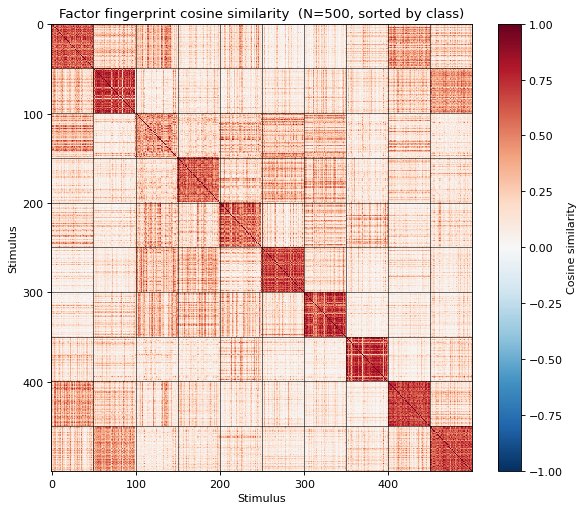

In [10]:
MAX_VIZ = 500
rng = np.random.default_rng(42)
# Stratified sample: keep up to MAX_VIZ//10 per class
viz_idx = np.concatenate([
    rng.choice(np.where(all_targets == c)[0],
               min(MAX_VIZ // 10, (all_targets == c).sum()), replace=False)
    for c in range(10)
])
viz_idx = viz_idx[np.argsort(all_targets[viz_idx])]

S = compute_stimulus_similarity(Fmat[viz_idx])
targets_viz = all_targets[viz_idx]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(S, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

for cl in range(10):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        ax.axhline(b + 0.5, color='k', lw=0.5, alpha=0.6)
        ax.axvline(b + 0.5, color='k', lw=0.5, alpha=0.6)

ax.set(title=f'Factor fingerprint cosine similarity  (N={len(viz_idx)}, sorted by class)',
       xlabel='Stimulus', ylabel='Stimulus')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


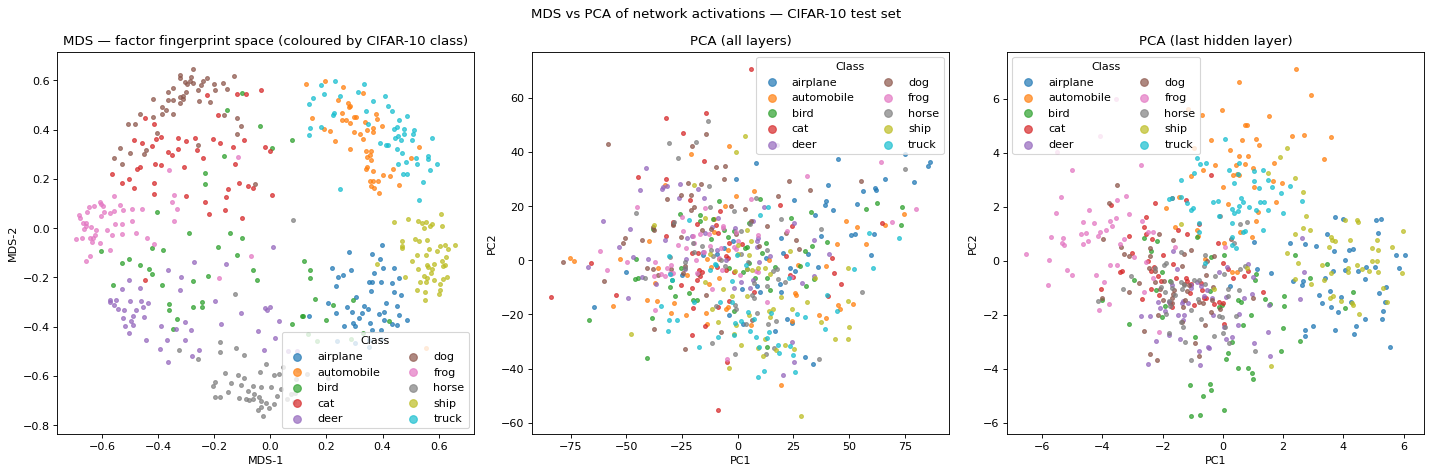

In [11]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA

dist_matrix = cosine_distances(Fmat[viz_idx])
coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(dist_matrix)

# PCA over neurons — same stimuli as MDS (flatten spatial dims for conv layers)
_li_sub  = np.hstack([l[viz_idx].reshape(len(viz_idx), -1) for l in layer_inputs])
_li_last = layer_inputs[-2][viz_idx].reshape(len(viz_idx), -1)
pca_all  = PCA(n_components=2).fit_transform(_li_sub)
pca_last = PCA(n_components=2).fit_transform(_li_last)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap_tab = plt.get_cmap('tab10')

for cl in range(10):
    mask = targets_viz == cl
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    c=[cmap_tab(cl)], s=12, alpha=0.7, label=CIFAR10_CLASSES[cl])
axes[0].legend(markerscale=2, title='Class', ncol=2)
axes[0].set(title='MDS — factor fingerprint space (coloured by CIFAR-10 class)',
            xlabel='MDS-1', ylabel='MDS-2')

for cl in range(10):
    mask = targets_viz == cl
    axes[1].scatter(pca_all[mask, 0], pca_all[mask, 1],
                    c=[cmap_tab(cl)], s=12, alpha=0.7, label=CIFAR10_CLASSES[cl])
axes[1].legend(markerscale=2, title='Class', ncol=2)
axes[1].set(title='PCA (all layers)', xlabel='PC1', ylabel='PC2')

for cl in range(10):
    mask = targets_viz == cl
    axes[2].scatter(pca_last[mask, 0], pca_last[mask, 1],
                    c=[cmap_tab(cl)], s=12, alpha=0.7, label=CIFAR10_CLASSES[cl])
axes[2].legend(markerscale=2, title='Class', ncol=2)
axes[2].set(title='PCA (last hidden layer)', xlabel='PC1', ylabel='PC2')

plt.suptitle('MDS vs PCA of network activations — CIFAR-10 test set', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_mds.png'), dpi=120, bbox_inches='tight')
plt.show()

Intra-class similarity: 0.612 ± 0.145
Inter-class similarity: 0.179 ± 0.137

Per-class intra-class similarity:
  airplane    : 0.591 ± 0.123
  automobile  : 0.667 ± 0.136
  bird        : 0.435 ± 0.143
  cat         : 0.584 ± 0.110
  deer        : 0.570 ± 0.136
  dog         : 0.631 ± 0.119
  frog        : 0.681 ± 0.136
  horse       : 0.660 ± 0.149
  ship        : 0.650 ± 0.099
  truck       : 0.646 ± 0.110


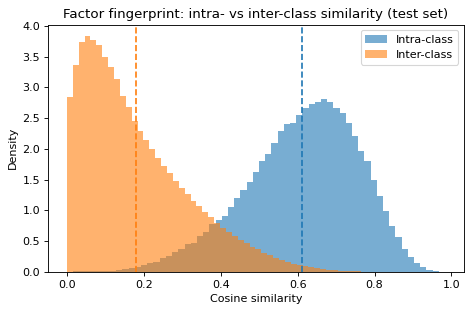

In [12]:
S_all = compute_stimulus_similarity(Fmat)
classes = list(range(10))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())

intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class similarity: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class similarity: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')

print('\nPer-class intra-class similarity:')
for cl in classes:
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    vals  = intra[np.triu_indices_from(intra, k=1)]
    print(f'  {CIFAR10_CLASSES[cl]:12s}: {vals.mean():.3f} ± {vals.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra- vs inter-class similarity (test set)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'intra_inter_stats.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 4: ID Sanity Check

Project **training** CIFAR-10 samples (top-N_TOP_PER_CLASS by confidence) onto the
fixed BFT factors and compare factor activation patterns to the **test** samples.

In [13]:
train_tf_eval = T.Compose([T.ToTensor(), normalize])
train_ds  = torchvision.datasets.CIFAR10(DATA_DIR, train=True, download=True,
                                          transform=train_tf_eval)
train_loader = DataLoader(train_ds, 256, shuffle=False, num_workers=0)

print('Collecting training set layer data (this may take a minute)...')
raw_train = collect_layer_data(model, train_loader, DEVICE, only_correct=True)
print(f'Correct training samples: {len(raw_train["targets"]):,}')

data_train, _ = confidence_filter(raw_train, N_TOP_PER_CLASS)
train_images  = data_train['images']
train_targets = data_train['targets']
train_layer_inputs = [ld['input_fmap'] for ld in data_train['layer_data']]
print(f'After confidence filter: N = {len(train_images)}')
print(f'Class dist: {dict(zip(*np.unique(train_targets, return_counts=True)))}')

Correct training samples: 40,670
After confidence filter: N = 2000
Class dist: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}


In [14]:
projected_train_root = project_stimuli_onto_tree(tree_root, train_layer_inputs)
factor_nodes_train   = extract_factor_tree_nodes(projected_train_root)

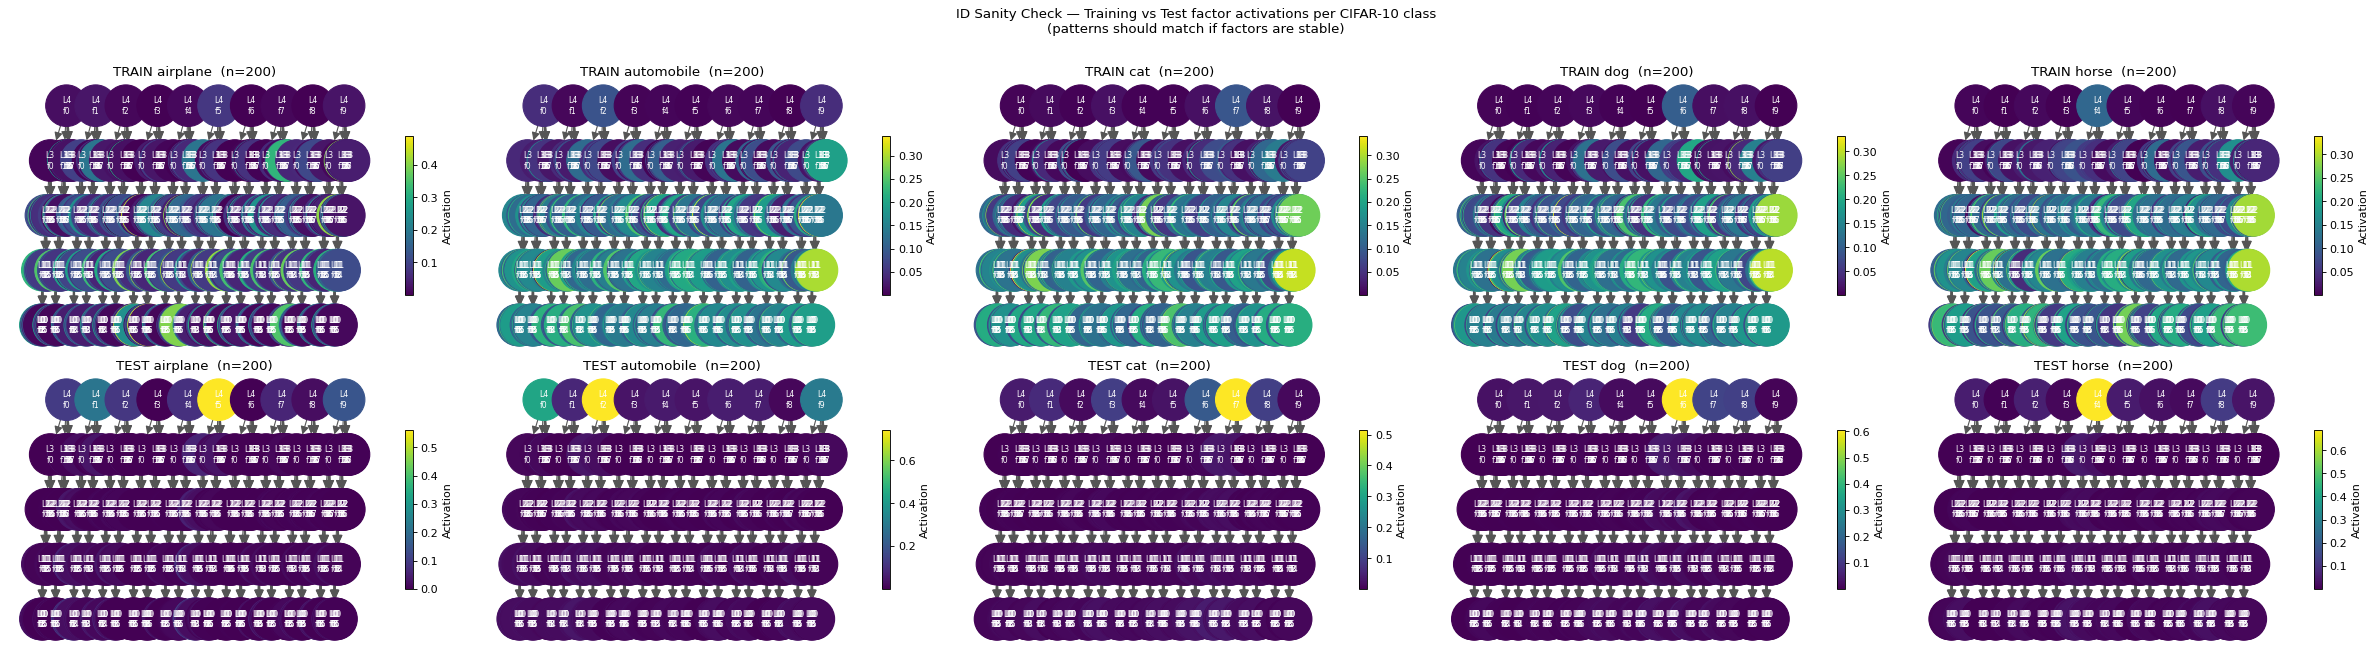

In [15]:
# Side-by-side tree per class: training vs test
# Show 5 representative classes to keep the plot manageable
SHOW_CLASSES = [0, 1, 3, 5, 7]  # airplane, auto, cat, sandal, horse

fig, axes = plt.subplots(2, len(SHOW_CLASSES), figsize=(6 * len(SHOW_CLASSES), 8))

for col, cl in enumerate(SHOW_CLASSES):
    train_cl_idx = np.where(train_targets == cl)[0]
    acts_train = compute_factor_activations(factor_nodes_train, train_cl_idx)
    plot_factor_tree(factor_nodes_train, acts_train, ax=axes[0, col],
                     title=f'TRAIN {CIFAR10_CLASSES[cl]}  (n={len(train_cl_idx)})')

    test_cl_idx = np.where(all_targets == cl)[0]
    acts_test = compute_factor_activations(factor_nodes, test_cl_idx)
    plot_factor_tree(factor_nodes, acts_test, ax=axes[1, col],
                     title=f'TEST {CIFAR10_CLASSES[cl]}  (n={len(test_cl_idx)})')

plt.suptitle('ID Sanity Check — Training vs Test factor activations per CIFAR-10 class\n'
             '(patterns should match if factors are stable)', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_tree_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

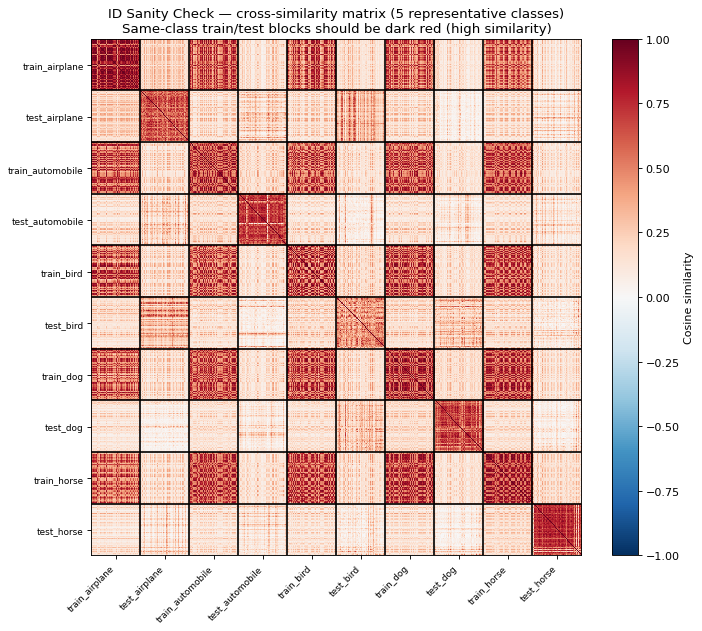

In [16]:
N_PER_SPLIT = 50
rng = np.random.default_rng(0)
SHOW_CL = [0, 1, 2, 5, 7]  # 5 representative classes

splits = {}
for cl in SHOW_CL:
    cl_name = CIFAR10_CLASSES[cl]
    tr_idx = np.where(train_targets == cl)[0]
    if len(tr_idx) > N_PER_SPLIT:
        tr_idx = rng.choice(tr_idx, N_PER_SPLIT, replace=False)
    splits[f'train_{cl_name}'] = extract_fingerprint_matrix(projected_train_root, tr_idx)

    te_idx = np.where(all_targets == cl)[0]
    if len(te_idx) > N_PER_SPLIT:
        te_idx = rng.choice(te_idx, N_PER_SPLIT, replace=False)
    splits[f'test_{cl_name}'] = extract_fingerprint_matrix(tree_root, te_idx)

split_labels = list(splits.keys())
F_blocks     = np.concatenate(list(splits.values()), axis=0)
block_sizes  = [len(v) for v in splits.values()]
block_starts = [0] + list(np.cumsum(block_sizes[:-1]))
block_ends   = list(np.cumsum(block_sizes))
boundaries   = np.array(block_ends[:-1])
S_cross      = compute_stimulus_similarity(F_blocks)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(S_cross, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

for b in boundaries:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)

centres = np.array(block_starts) + np.array(block_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(split_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(centres); ax.set_yticklabels(split_labels, fontsize=8)
ax.set_title('ID Sanity Check — cross-similarity matrix (5 representative classes)\n'
             'Same-class train/test blocks should be dark red (high similarity)')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_fingerprint_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


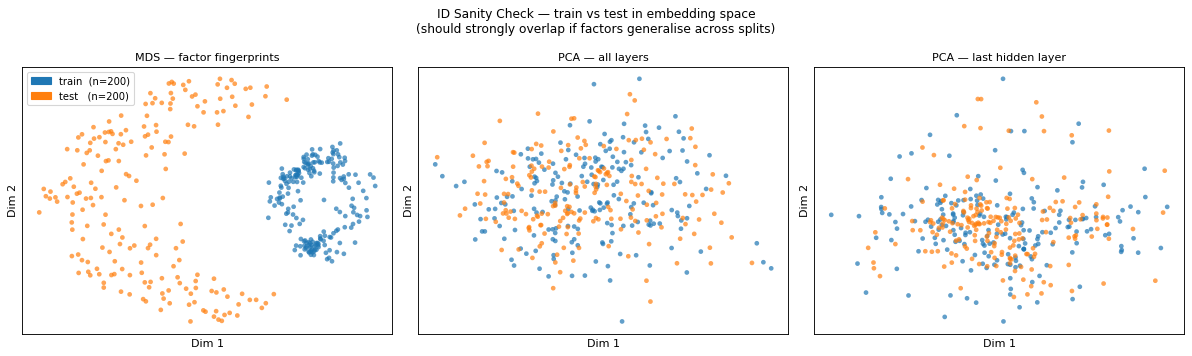

In [27]:
# ── MDS + PCA: training vs test colored by split (ID sanity check) ────────────
N_SAMPLE_ID = 200
rng_id = np.random.default_rng(42)

n_train_id = len(train_images)
tr_sub = rng_id.choice(n_train_id, min(N_SAMPLE_ID, n_train_id), replace=False)
te_sub = rng_id.choice(n_samples,  min(N_SAMPLE_ID, n_samples),  replace=False)
n_tr, n_te = len(tr_sub), len(te_sub)

# Factor fingerprints (train projected, test from original tree)
F_tr    = extract_fingerprint_matrix(projected_train_root, tr_sub)
F_te    = extract_fingerprint_matrix(tree_root, te_sub)
F_joint = np.concatenate([F_tr, F_te], axis=0)

# MDS on fingerprint cosine distances
coords_mds_id = MDS(n_components=2, dissimilarity='precomputed',
                    random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))

# PCA on raw layer activations — flatten spatial dims for conv layers
li_joint_all = np.concatenate([
    np.hstack([l[tr_sub].reshape(n_tr, -1) for l in train_layer_inputs]),
    np.hstack([l[te_sub].reshape(n_te, -1) for l in layer_inputs]),
], axis=0)
pca_all_id = PCA(n_components=2).fit_transform(li_joint_all)

# PCA on last hidden layer only
li_joint_last = np.concatenate([
    train_layer_inputs[-2][tr_sub].reshape(n_tr, -1),
    layer_inputs[-2][te_sub].reshape(n_te, -1),
], axis=0)
pca_last_id = PCA(n_components=2).fit_transform(li_joint_last)

# Plot — blue = train, orange = test
colors = ['#1f77b4'] * n_tr + ['#ff7f0e'] * n_te
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#1f77b4', label=f'train  (n={n_tr})'),
    mpatches.Patch(color='#ff7f0e', label=f'test   (n={n_te})'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, coords, title in zip(
    axes,
    [coords_mds_id, pca_all_id, pca_last_id],
    ['MDS — factor fingerprints', 'PCA — all layers', 'PCA — last hidden layer'],
):
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=18, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(handles=legend_handles, loc='best', fontsize=9)
plt.suptitle('ID Sanity Check — train vs test in embedding space\n'
             '(should strongly overlap if factors generalise across splits)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_mds_pca_train_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Real OOD — CIFAR-100

The SmallCNN was trained on **all 10 CIFAR-10 classes** — no excluded classes to use as
near-OOD.  Instead we use **CIFAR-100**: 10,000 test images across 100 fine-grained
categories, the same 32×32 RGB format and similar natural image statistics.

We apply CIFAR-10 normalisation to CIFAR-100 images (slight distribution mismatch
is intentional — the model receives genuinely OOD inputs).  The model's output
classes (0–9) have no correspondence to CIFAR-100 labels (0–99).

In [17]:
# Apply CIFAR-10 normalisation to CIFAR-100 (intentional slight mismatch)
cifar100_test = torchvision.datasets.CIFAR100(
    DATA_DIR, train=False, download=True,
    transform=T.Compose([T.ToTensor(), normalize])  # CIFAR-10 norm on CIFAR-100
)
cifar100_loader = DataLoader(cifar100_test, 256, shuffle=False, num_workers=0)

print('Collecting CIFAR-100 layer data (OOD) ...')
raw_ood = collect_layer_data(model, cifar100_loader, DEVICE, only_correct=False)
ood_images  = raw_ood['images']   # (N, 3, 32, 32) normalised
ood_targets = raw_ood['targets']  # CIFAR-100 true class labels (0–99)
n_ood = len(ood_images)

# Compute model predictions separately
model.eval()
ood_preds_list = []
with torch.no_grad():
    for x, _ in cifar100_loader:
        ood_preds_list.append(model(x.to(DEVICE)).argmax(1).cpu().numpy())
ood_preds = np.concatenate(ood_preds_list)  # predicted CIFAR-10 class (0–9)

ood_layer_inputs = [ld['input_fmap'] for ld in raw_ood['layer_data']]

# Pseudo-accuracy: proportion where predicted CIFAR-10 label == CIFAR-100 coarse label
# (not meaningful; reported for sanity)
ood_acc_chance = (ood_preds == (ood_targets % 10)).mean()
print(f'CIFAR-100 OOD samples    : {n_ood}')
print(f'Pred distribution        : {dict(zip(*np.unique(ood_preds, return_counts=True)))}')
print(f'(pseudo-acc ≈ 10% chance): {ood_acc_chance:.3f}')

CIFAR-100 OOD samples    : 10000
Pred distribution        : {np.int64(0): np.int64(1043), np.int64(1): np.int64(328), np.int64(2): np.int64(1372), np.int64(3): np.int64(1579), np.int64(4): np.int64(971), np.int64(5): np.int64(1386), np.int64(6): np.int64(1229), np.int64(7): np.int64(593), np.int64(8): np.int64(686), np.int64(9): np.int64(813)}
(pseudo-acc ≈ 10% chance): 0.102


In [18]:
# Project CIFAR-100 samples onto the fixed CIFAR-10 BFT factors via NNLS
projected_ood_root = project_stimuli_onto_tree(tree_root, ood_layer_inputs)
factor_nodes_ood   = extract_factor_tree_nodes(projected_ood_root)
print('Projection complete.')

Projection complete.


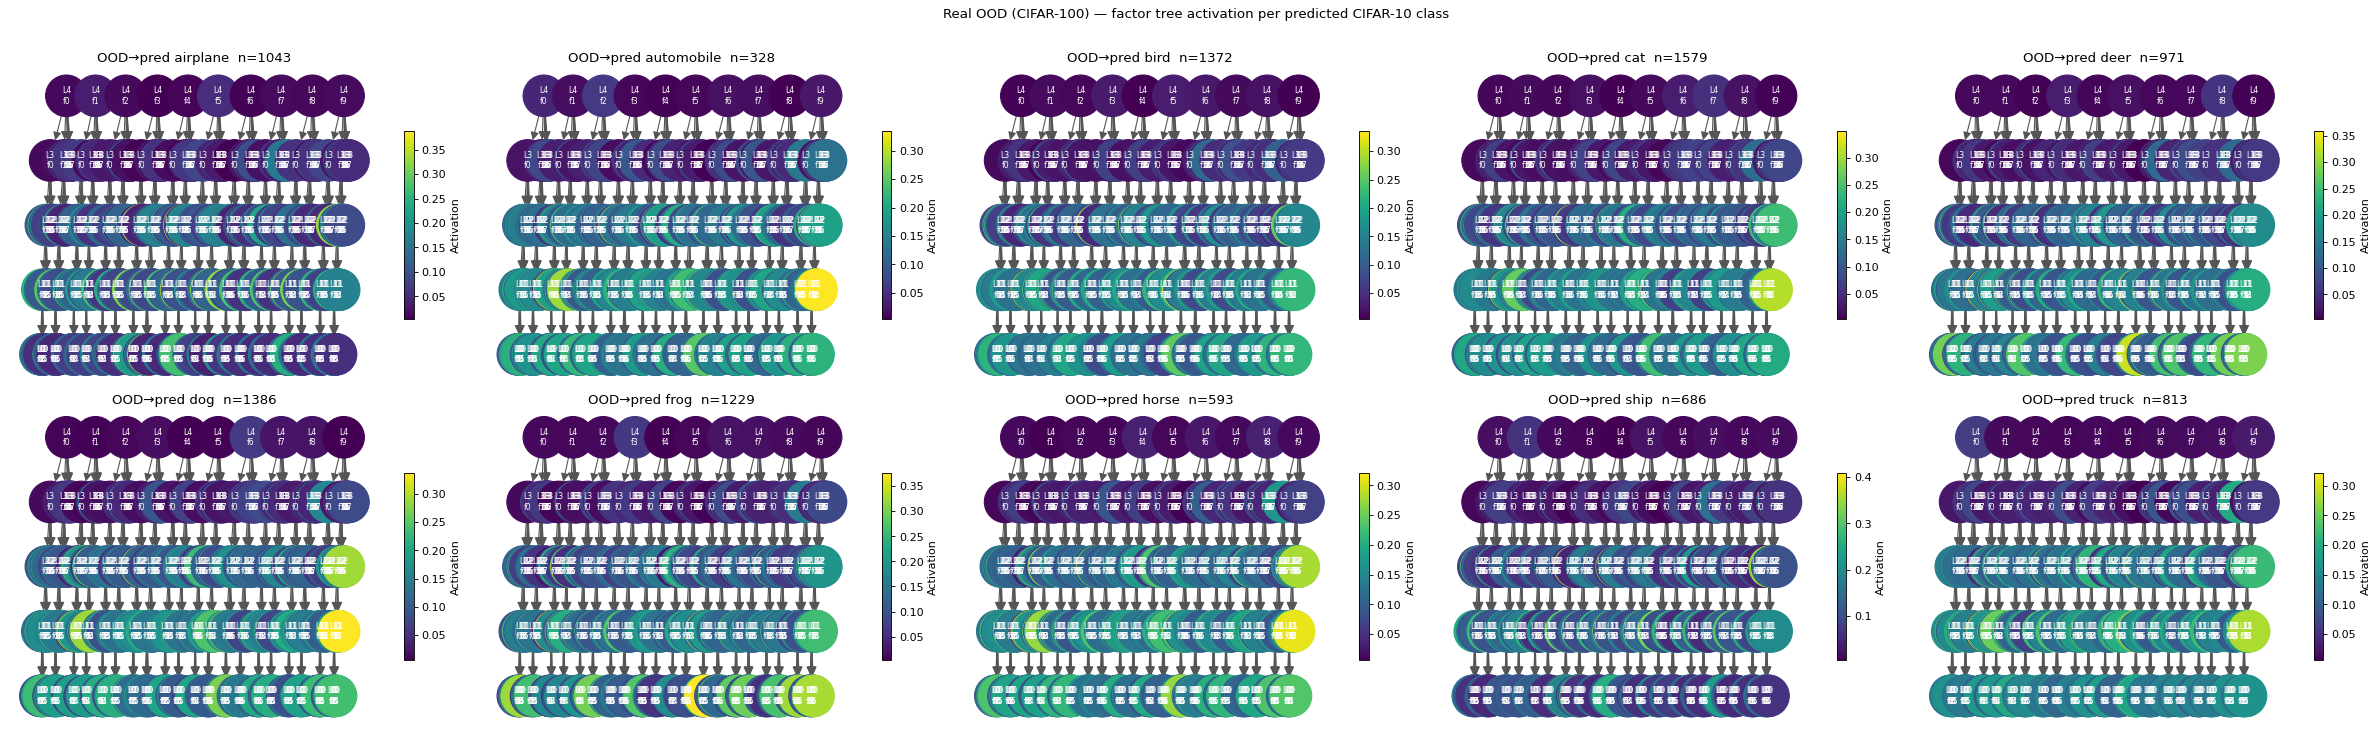

In [19]:
# ── Tree per CIFAR-10 predicted class for the OOD (CIFAR-100) samples ─────────
# (groups OOD images by which CIFAR-10 class the digit model fires at)
unique_preds = sorted(np.unique(ood_preds))
ncols = min(5, len(unique_preds))
nrows = int(np.ceil(len(unique_preds) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

for i, cl in enumerate(unique_preds):
    ax = axes[i // ncols][i % ncols]
    cl_idx = np.where(ood_preds == cl)[0]
    acts = compute_factor_activations(factor_nodes_ood, cl_idx)
    plot_factor_tree(
        factor_nodes_ood, acts, ax=ax,
        title=f'OOD→pred {CIFAR10_CLASSES[cl]}  n={len(cl_idx)}',
    )

for j in range(len(unique_preds), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Real OOD (CIFAR-100) — factor tree activation per predicted CIFAR-10 class',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_tree_per_predicted_class.png'), dpi=120, bbox_inches='tight')
plt.show()

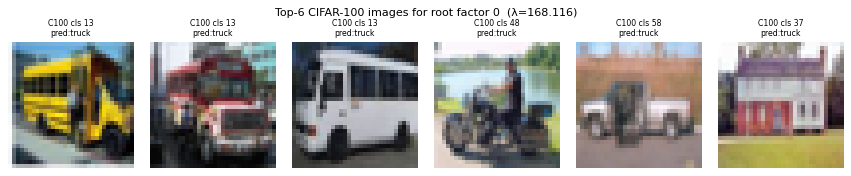

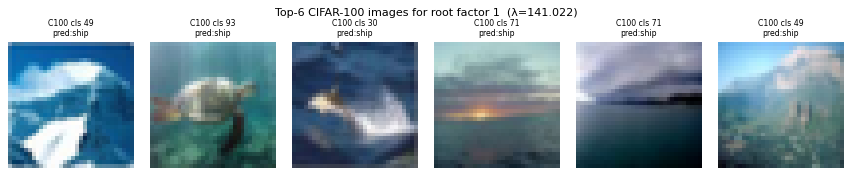

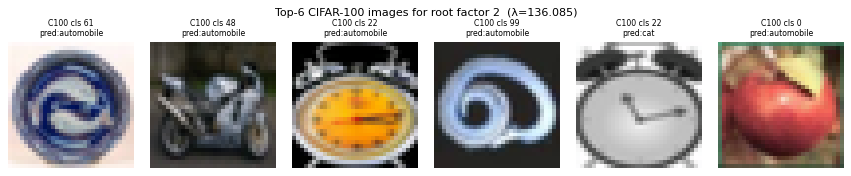

In [20]:
_inline_shown_ood_ex = 0
_MAX_INLINE_ood_ex  = 3

# ── Gallery: top-factor CIFAR-100 images vs the ID CIFAR-10 images they are most similar to ──
# For each CIFAR-10 output factor, show the top-6 CIFAR-100 images with highest loading
K_root = len(root_bft_node['lambdas'])
N_GALLERY = 6

for k in range(min(K_root, 4)):  # show first 4 root factors
    loadings = projected_ood_root['img_factors'][:, k]
    top_idx  = np.argsort(loadings)[::-1][:N_GALLERY]

    fig, axes = plt.subplots(1, N_GALLERY, figsize=(N_GALLERY * 1.8, 2.2))
    for col, idx in enumerate(top_idx):
        axes[col].imshow(imdenorm(ood_images[idx]))
        axes[col].set_title(f'C100 cls {ood_targets[idx]}\npred:{CIFAR10_CLASSES[ood_preds[idx]]}',
                            fontsize=7)
        axes[col].axis('off')
    fig.suptitle(f'Top-{N_GALLERY} CIFAR-100 images for root factor {k}  (λ={root_bft_node["lambdas"][k]:.3f})',
                 fontsize=10)
    plt.tight_layout()
    fname = os.path.join(FIG_DIR, f'ood_gallery_factor{k}.png')
    fig.savefig(fname, dpi=120, bbox_inches='tight')
    if _inline_shown_ood_ex < _MAX_INLINE_ood_ex:
        _inline_shown_ood_ex += 1
        plt.show()
    else:
        plt.close(fig)

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


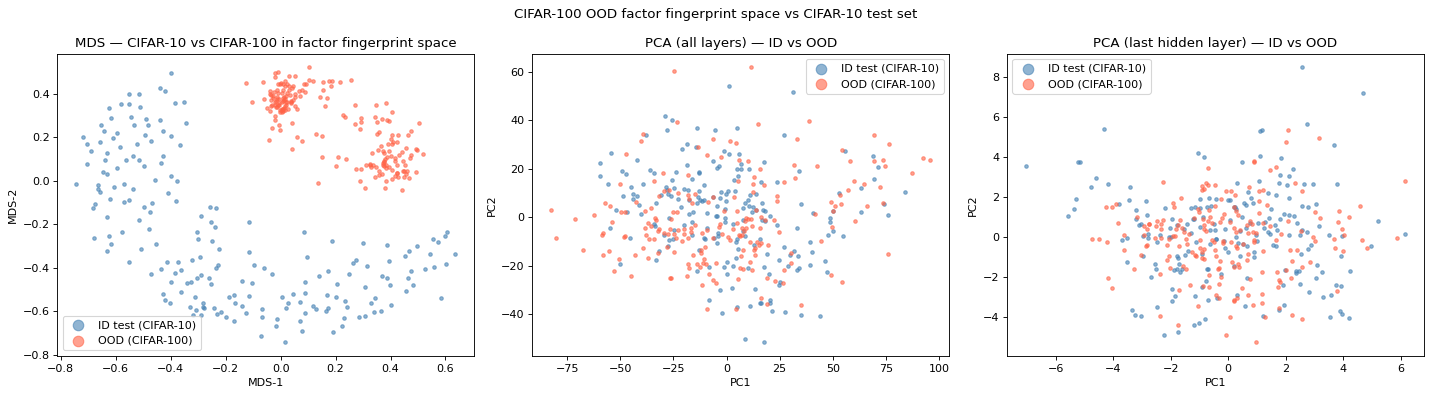

In [21]:
N_ID_SAMPLE  = 200
N_OOD_SAMPLE = min(200, n_ood)

rng = np.random.default_rng(1)
id_sub   = rng.choice(n_samples, N_ID_SAMPLE, replace=False)
ood_sub  = rng.choice(n_ood,     N_OOD_SAMPLE, replace=False)

F_id      = extract_fingerprint_matrix(tree_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood_root, ood_sub)
F_joint   = np.concatenate([F_id, F_ood_sub], axis=0)

coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(
    cosine_distances(F_joint)
)

# PCA over neurons for the same joint stimulus set (flatten spatial dims for conv layers)
_n_id = len(id_sub); _n_ood = len(ood_sub)
_li_id   = np.hstack([l[id_sub].reshape(_n_id, -1)  for l in layer_inputs])
_li_ood  = np.hstack([l[ood_sub].reshape(_n_ood, -1) for l in ood_layer_inputs])
_li_joint_all  = np.vstack([_li_id,  _li_ood])
_li_joint_last = np.vstack([
    layer_inputs[-2][id_sub].reshape(_n_id, -1),
    ood_layer_inputs[-2][ood_sub].reshape(_n_ood, -1),
])
pca_all  = PCA(n_components=2).fit_transform(_li_joint_all)
pca_last = PCA(n_components=2).fit_transform(_li_joint_last)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap_tab = plt.get_cmap('tab10')

# MDS: ID vs OOD
axes[0].scatter(coords[:N_ID_SAMPLE, 0], coords[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (CIFAR-10)')
axes[0].scatter(coords[N_ID_SAMPLE:, 0], coords[N_ID_SAMPLE:, 1],
                c='tomato', s=10, alpha=0.6, label='OOD (CIFAR-100)')
axes[0].legend(markerscale=3)
axes[0].set(title='MDS — CIFAR-10 vs CIFAR-100 in factor fingerprint space',
            xlabel='MDS-1', ylabel='MDS-2')

# PCA — all layers, ID/OOD colouring
axes[1].scatter(pca_all[:N_ID_SAMPLE, 0], pca_all[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (CIFAR-10)')
axes[1].scatter(pca_all[N_ID_SAMPLE:, 0], pca_all[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD (CIFAR-100)')
axes[1].legend(markerscale=3)
axes[1].set(title='PCA (all layers) — ID vs OOD', xlabel='PC1', ylabel='PC2')

# PCA — last hidden layer, ID/OOD colouring
axes[2].scatter(pca_last[:N_ID_SAMPLE, 0], pca_last[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (CIFAR-10)')
axes[2].scatter(pca_last[N_ID_SAMPLE:, 0], pca_last[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD (CIFAR-100)')
axes[2].legend(markerscale=3)
axes[2].set(title='PCA (last hidden layer) — ID vs OOD', xlabel='PC1', ylabel='PC2')

plt.suptitle('CIFAR-100 OOD factor fingerprint space vs CIFAR-10 test set', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_fingerprint_mds.png'), dpi=120, bbox_inches='tight')
plt.show()

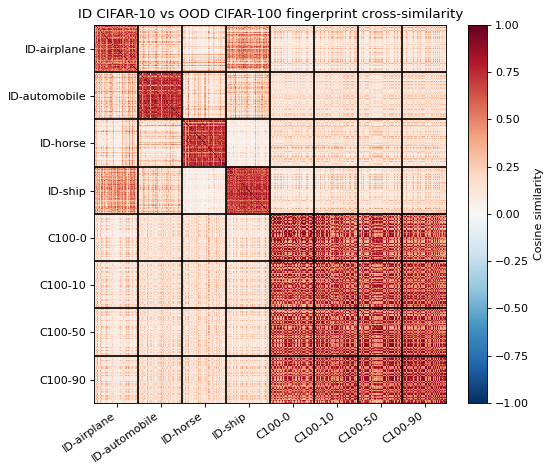

In [22]:
N_BLOCK = 60
rng_block = np.random.default_rng(2)
BLOCK_ID  = [0, 1, 7, 8]   # airplane, auto, horse, ship (ID CIFAR-10)

blocks = {}
for cl in BLOCK_ID:
    idx = rng_block.choice(np.where(all_targets == cl)[0],
                            min(N_BLOCK, (all_targets == cl).sum()), replace=False)
    blocks[f'ID-{CIFAR10_CLASSES[cl]}'] = extract_fingerprint_matrix(tree_root, idx)

# Sample representative CIFAR-100 superclasses (0=aquatic mammals, 10=fruit, 50=insects)
for c100 in [0, 10, 50, 90]:
    idx = np.where(ood_targets == c100)[0]
    if len(idx) == 0:
        continue
    idx = rng_block.choice(idx, min(N_BLOCK, len(idx)), replace=False)
    blocks[f'C100-{c100}'] = extract_fingerprint_matrix(projected_ood_root, idx)

block_labels  = list(blocks.keys())
F_all_blocks  = np.concatenate(list(blocks.values()), axis=0)
bl_sizes      = [len(v) for v in blocks.values()]
bl_starts     = [0] + list(np.cumsum(bl_sizes[:-1]))
bl_ends       = list(np.cumsum(bl_sizes))
bounds        = np.array(bl_ends[:-1])
S_blocks      = compute_stimulus_similarity(F_all_blocks)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S_blocks, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')
for b in bounds:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)
centres = np.array(bl_starts) + np.array(bl_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(block_labels, rotation=35, ha='right')
ax.set_yticks(centres); ax.set_yticklabels(block_labels)
ax.set_title('ID CIFAR-10 vs OOD CIFAR-100 fingerprint cross-similarity')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_cross_similarity.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 5b: Far OOD — Synthetic 3-channel images

Four synthetic RGB image types (matched to CIFAR-10's 32×32 3-channel format):
- **gaussian_noise** — i.i.d. pixels ~ N(0.5, 0.25²) per channel, clipped to [0, 1]
- **uniform_gray** — constant mid-grey across all 3 channels (0.5)
- **checkerboard** — hard 0/1 alternating pattern replicated across R/G/B
- **inverted_test** — colour-inverted test images (unnormalise → invert → renormalise)

In [23]:
N_FAR  = 200
C, H, W = 3, IMAGE_SIDE, IMAGE_SIDE
rng_f  = np.random.default_rng(99)

_chk   = (np.indices((H, W)).sum(axis=0) % 2).astype(np.float32)  # (H, W) checkerboard
_chk3  = np.broadcast_to(_chk[None], (1, H, W)).copy()             # (1, H, W)

# Inverted test images: unnormalise → invert → renormalise
_mn = CIFAR10_MEAN[:, None, None]; _st = CIFAR10_STD[:, None, None]
_orig     = all_images[:N_FAR] * _st + _mn          # unnormalise to [0,1]
_inverted = np.clip(1.0 - _orig, 0, 1)              # invert
_inv_norm = (_inverted - _mn) / _st                  # renormalise

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR, C, H, W)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR, C, H, W), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk3, (N_FAR, C, H, W)).copy().astype(np.float32),
    'inverted_test':  _inv_norm.astype(np.float32),
}

def collect_far_ood_cifar(model, images_np, device, batch_size=128):
    dataset = TensorDataset(
        torch.from_numpy(images_np),
        torch.zeros(len(images_np), dtype=torch.long),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return collect_layer_data(model, loader, device, only_correct=False)

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    d = collect_far_ood_cifar(model, imgs, DEVICE)
    li = [ld['input_fmap'] for ld in d['layer_data']]
    d['layer_inputs']   = li
    d['projected_root'] = project_stimuli_onto_tree(tree_root, li)
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name] = d
    print(f'{name:20s}  n={len(imgs)}')

gaussian_noise        n=200
uniform_gray          n=200
checkerboard          n=200
inverted_test         n=200


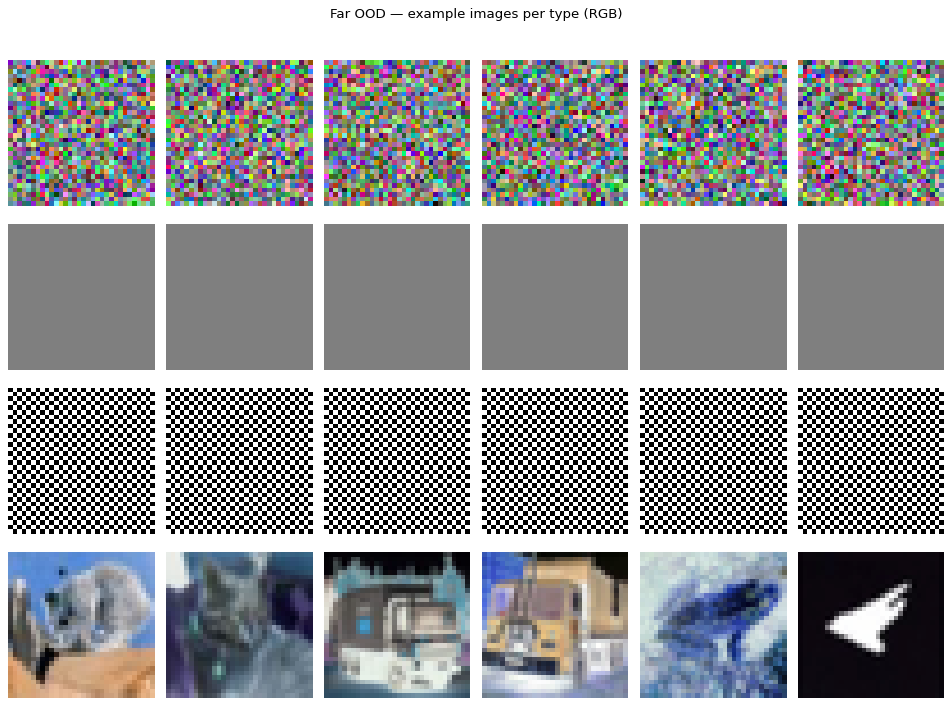

In [24]:
n_examples = 6
fig, axes = plt.subplots(len(far_ood_arrays), n_examples,
                          figsize=(n_examples * 2, len(far_ood_arrays) * 2.2))
for row, name in enumerate(far_ood_arrays):
    imgs = far_ood_arrays[name]
    for col in range(n_examples):
        img = imgs[col]
        # Raw synthetic images are in [0,1] pixel space (not normalised) — display directly
        if name == 'inverted_test':
            axes[row, col].imshow(imdenorm(img))   # renormalised → undo for display
        else:
            axes[row, col].imshow(np.clip(img.transpose(1, 2, 0), 0, 1))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=30, ha='right', va='center')
plt.suptitle('Far OOD — example images per type (RGB)', y=1.01, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_examples.png'), dpi=120, bbox_inches='tight')
plt.show()

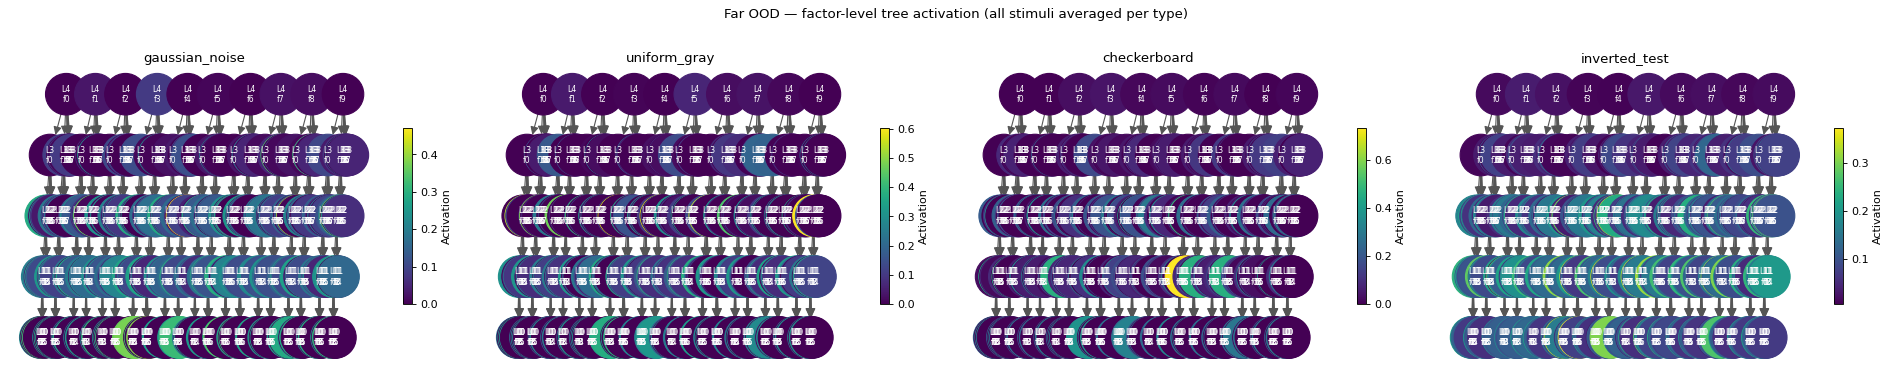

In [25]:
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]

for ax, (name, d) in zip(axes, far_ood_data.items()):
    all_idx = np.arange(len(d['images']))
    acts    = compute_factor_activations(d['factor_nodes'], all_idx)
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)

plt.suptitle('Far OOD — factor-level tree activation (all stimuli averaged per type)',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.png'), dpi=120, bbox_inches='tight')
plt.show()

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


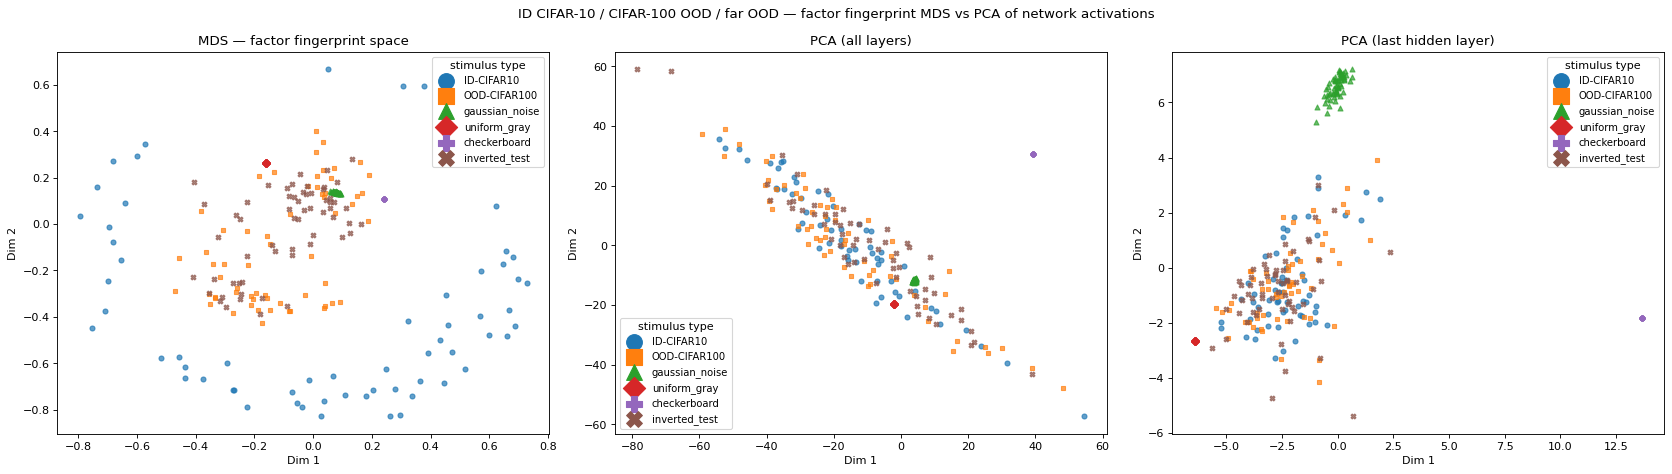

In [26]:
# ── MDS + PCA: ID test / CIFAR-100 OOD / far OOD in factor fingerprint space ──
N_EACH_MDS = 60
rng_m = np.random.default_rng(7)

F_parts, li_all_parts, li_last_parts = [], [], []
mds_labels, mds_markers = [], []

# ID test
id_sub = rng_m.choice(n_samples, min(N_EACH_MDS, n_samples), replace=False)
_n = len(id_sub)
F_parts.append(extract_fingerprint_matrix(tree_root, id_sub))
li_all_parts.append(np.hstack([l[id_sub].reshape(_n, -1) for l in layer_inputs]))
li_last_parts.append(layer_inputs[-2][id_sub].reshape(_n, -1))
mds_labels  += ['ID-CIFAR10'] * _n
mds_markers += ['o'] * _n

# CIFAR-100 OOD
ood_sub = rng_m.choice(n_ood, min(N_EACH_MDS, n_ood), replace=False)
_n = len(ood_sub)
F_parts.append(extract_fingerprint_matrix(projected_ood_root, ood_sub))
li_all_parts.append(np.hstack([l[ood_sub].reshape(_n, -1) for l in ood_layer_inputs]))
li_last_parts.append(ood_layer_inputs[-2][ood_sub].reshape(_n, -1))
mds_labels  += ['OOD-CIFAR100'] * _n
mds_markers += ['s'] * _n

# Far OOD types
marker_cycle = ['^', 'D', 'P', 'X']
for (name, d), mkr in zip(far_ood_data.items(), marker_cycle):
    n = min(N_EACH_MDS, len(d['images']))
    sub = rng_m.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], sub))
    li_all_parts.append(np.hstack([l[sub].reshape(n, -1) for l in d['layer_inputs']]))
    li_last_parts.append(d['layer_inputs'][-2][sub].reshape(n, -1))
    mds_labels  += [name] * n
    mds_markers += [mkr] * n

F_joint    = np.concatenate(F_parts, axis=0)
coords_mds = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))
pca_all  = PCA(n_components=2).fit_transform(np.vstack(li_all_parts))
pca_last = PCA(n_components=2).fit_transform(np.vstack(li_last_parts))

unique_labels = list(dict.fromkeys(mds_labels))
cmap_tab = plt.get_cmap('tab10')
label_color  = {l: cmap_tab(i % 10) for i, l in enumerate(unique_labels)}
label_marker = dict(zip(mds_labels, mds_markers))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for embed, ax, title in [
    (coords_mds, axes[0], 'MDS — factor fingerprint space'),
    (pca_all,    axes[1], 'PCA (all layers)'),
    (pca_last,   axes[2], 'PCA (last hidden layer)'),
]:
    for i, lbl in enumerate(mds_labels):
        ax.scatter(embed[i, 0], embed[i, 1],
                   c=[label_color[lbl]], marker=label_marker[lbl], s=20, alpha=0.7)
    for lbl in unique_labels:
        ax.scatter([], [], c=[label_color[lbl]], marker=label_marker[lbl], s=50, label=lbl)
    ax.legend(markerscale=2, ncol=1, fontsize=9, title='stimulus type')
    ax.set(title=title, xlabel='Dim 1', ylabel='Dim 2')

plt.suptitle('ID CIFAR-10 / CIFAR-100 OOD / far OOD — factor fingerprint MDS vs PCA of network activations',
             fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_mds.png'), dpi=120, bbox_inches='tight')
plt.show()